In [1]:
from pathlib import Path
import json, time, cv2, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

ROOT=Path("/homes/mxqasim/Chocolathon")
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
BOX_DIR=ROOT/"data/experiments/box_localization_v1/outputs"
DEPLOY_DIR=ROOT/"data/experiments/synthetic_slot_embeddings_v1/deployment"

PATHS={
    "box_size":BOX_DIR/"efficientnet_b0_box_size_classifier.pt",
    "corners":BOX_DIR/"efficientnet_b0_spatial_corner_regressor.pt",
    "features":DEPLOY_DIR/"efficientnet_b0_feature_extractor.pt",
    "prototypes":DEPLOY_DIR/"slot_class_prototypes.npz",
    "catalog":DEPLOY_DIR/"class_catalog.csv",
    "config":DEPLOY_DIR/"deployment_config.json"
}

for name,path in PATHS.items():
    assert path.exists(),f"Missing {name}: {path}"
    print(f"✓ {name:12s} {path.name:50s} {path.stat().st_size/1024**2:.2f} MB")

CONFIG=json.loads(PATHS["config"].read_text())
CATALOG=pd.read_csv(PATHS["catalog"]).sort_values("class_index").reset_index(drop=True)
archive=np.load(PATHS["prototypes"],allow_pickle=True)
PROTOTYPES=torch.from_numpy(archive["prototypes"]).float().to(DEVICE)
CLASS_IDS=archive["class_ids"].astype(str)

assert PROTOTYPES.shape==(34,1280)
assert CATALOG["flavor_id"].tolist()==CLASS_IDS.tolist()
print(f"\nDevice: {DEVICE}")
print(f"Classes: {len(CLASS_IDS)} | Prototypes: {tuple(PROTOTYPES.shape)}")
print("Artifact validation: PASS")

/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


✓ box_size     efficientnet_b0_box_size_classifier.pt             16.21 MB
✓ corners      efficientnet_b0_spatial_corner_regressor.pt        18.97 MB
✓ features     efficientnet_b0_feature_extractor.pt               15.58 MB
✓ prototypes   slot_class_prototypes.npz                          0.15 MB
✓ catalog      class_catalog.csv                                  0.00 MB
✓ config       deployment_config.json                             0.00 MB

Device: cpu
Classes: 34 | Prototypes: (34, 1280)
Artifact validation: PASS


In [2]:
class BoxSizeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        base=models.efficientnet_b0(weights=None)
        self.features=base.features
        self.avgpool=base.avgpool
        self.classifier=nn.Sequential(nn.Dropout(0.2),nn.Linear(1280,128),nn.ReLU(),nn.Dropout(0.2),nn.Linear(128,4))

    def forward(self,x):
        return self.classifier(torch.flatten(self.avgpool(self.features(x)),1))


class SpatialCornerRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=models.efficientnet_b0(weights=None).features
        self.regressor=nn.Sequential(
            nn.Conv2d(1280,64,1),nn.BatchNorm2d(64),nn.SiLU(),
            nn.AdaptiveAvgPool2d((7,7)),nn.Flatten(),
            nn.Linear(3136,256),nn.SiLU(),nn.Dropout(0.25),
            nn.Linear(256,8),nn.Sigmoid()
        )

    def forward(self,x):
        return self.regressor(self.features(x))


class SlotFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base=models.efficientnet_b0(weights=None)
        self.features=base.features
        self.avgpool=base.avgpool

    def forward(self,x):
        return F.normalize(torch.flatten(self.avgpool(self.features(x)),1),dim=1)


def load_weights(model,path):
    state=torch.load(path,map_location="cpu",weights_only=True)
    result=model.load_state_dict(state,strict=True)
    model.to(DEVICE).eval()
    print(f"✓ Loaded {path.name}: {result}")
    return model


box_size_model=load_weights(BoxSizeClassifier(),PATHS["box_size"])
corner_model=load_weights(SpatialCornerRegressor(),PATHS["corners"])
feature_model=load_weights(SlotFeatureExtractor(),PATHS["features"])

with torch.inference_mode():
    box_test=box_size_model(torch.zeros(1,3,224,224,device=DEVICE))
    corner_test=corner_model(torch.zeros(1,3,224,224,device=DEVICE))
    feature_test=feature_model(torch.zeros(1,3,224,224,device=DEVICE))

assert box_test.shape==(1,4)
assert corner_test.shape==(1,8)
assert feature_test.shape==(1,1280)
print("\nModel smoke test: PASS")
print("Box output:",tuple(box_test.shape))
print("Corner output:",tuple(corner_test.shape))
print("Feature output:",tuple(feature_test.shape))

✓ Loaded efficientnet_b0_box_size_classifier.pt: <All keys matched successfully>
✓ Loaded efficientnet_b0_spatial_corner_regressor.pt: <All keys matched successfully>
✓ Loaded efficientnet_b0_feature_extractor.pt: <All keys matched successfully>

Model smoke test: PASS
Box output: (1, 4)
Corner output: (1, 8)
Feature output: (1, 1280)


In [3]:
from PIL import ImageOps

BOX_CLASSES=[6,16,30,50]
IMAGE_EXTENSIONS={".jpg",".jpeg",".png"}

candidates=[
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    and p.stem.upper() in {f"IMG_{i}" for i in range(2019,2035)}
    and not any(x in str(p).lower() for x in ["normalized","oriented","slot","output","synthetic"])
]

assert candidates,"No original empty-box images found."
TEST_IMAGE=sorted(candidates)[0]
print("Test image:",TEST_IMAGE)

pil_image=ImageOps.exif_transpose(Image.open(TEST_IMAGE)).convert("RGB")
image_rgb=np.asarray(pil_image)
height,width=image_rgb.shape[:2]

model_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

x=model_transform(pil_image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    size_probabilities=box_size_model(x).softmax(1)[0].cpu().numpy()
    normalized_corners=corner_model(x)[0].cpu().numpy().reshape(4,2)

predicted_capacity=BOX_CLASSES[int(size_probabilities.argmax())]
predicted_corners=normalized_corners*np.array([width,height],dtype=np.float32)

print(f"Original size: {width} × {height}")
print("Box-size probabilities:")
for capacity,probability in zip(BOX_CLASSES,size_probabilities):
    print(f"  {capacity:2d} slots: {probability:.4f}")
print("Predicted capacity:",predicted_capacity)
print("Predicted corners [TL, TR, BR, BL]:\n",np.round(predicted_corners,1))

Test image: /homes/mxqasim/Chocolathon/data/boxes/previews/IMG_2019.jpg
Original size: 600 × 800
Box-size probabilities:
   6 slots: 1.0000
  16 slots: 0.0000
  30 slots: 0.0000
  50 slots: 0.0000
Predicted capacity: 6
Predicted corners [TL, TR, BR, BL]:
 [[ 41.9 190.7]
 [254.5 214.1]
 [247.3 509.6]
 [ 39.  526.1]]


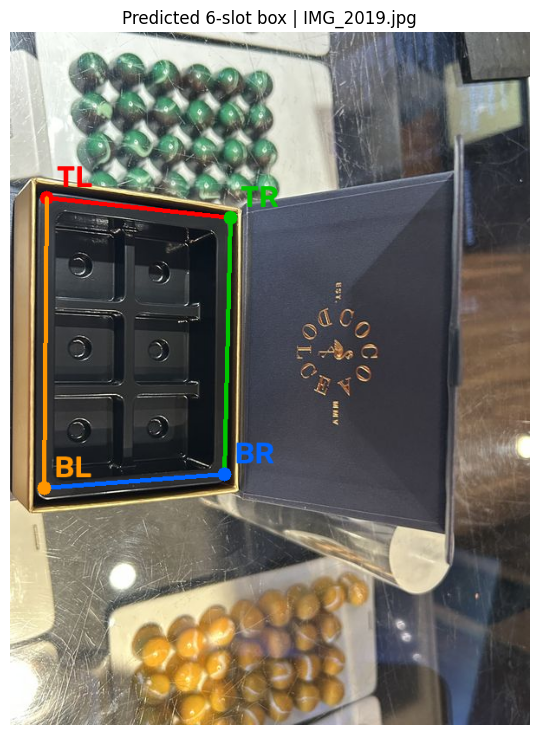

In [4]:
display_image=image_rgb.copy()
colors=[(255,0,0),(0,200,0),(0,100,255),(255,150,0)]
labels=["TL","TR","BR","BL"]

for i,(point,color,label) in enumerate(zip(predicted_corners,colors,labels)):
    x_coord,y_coord=np.round(point).astype(int)
    cv2.circle(display_image,(x_coord,y_coord),max(8,width//250),color,-1)
    cv2.putText(display_image,label,(x_coord+12,y_coord-12),cv2.FONT_HERSHEY_SIMPLEX,1.2,color,3)
    next_point=np.round(predicted_corners[(i+1)%4]).astype(int)
    cv2.line(display_image,(x_coord,y_coord),tuple(next_point),color,max(4,width//700))

plt.figure(figsize=(11,9))
plt.imshow(display_image)
plt.title(f"Predicted {predicted_capacity}-slot box | {TEST_IMAGE.name}")
plt.axis("off")
plt.show()

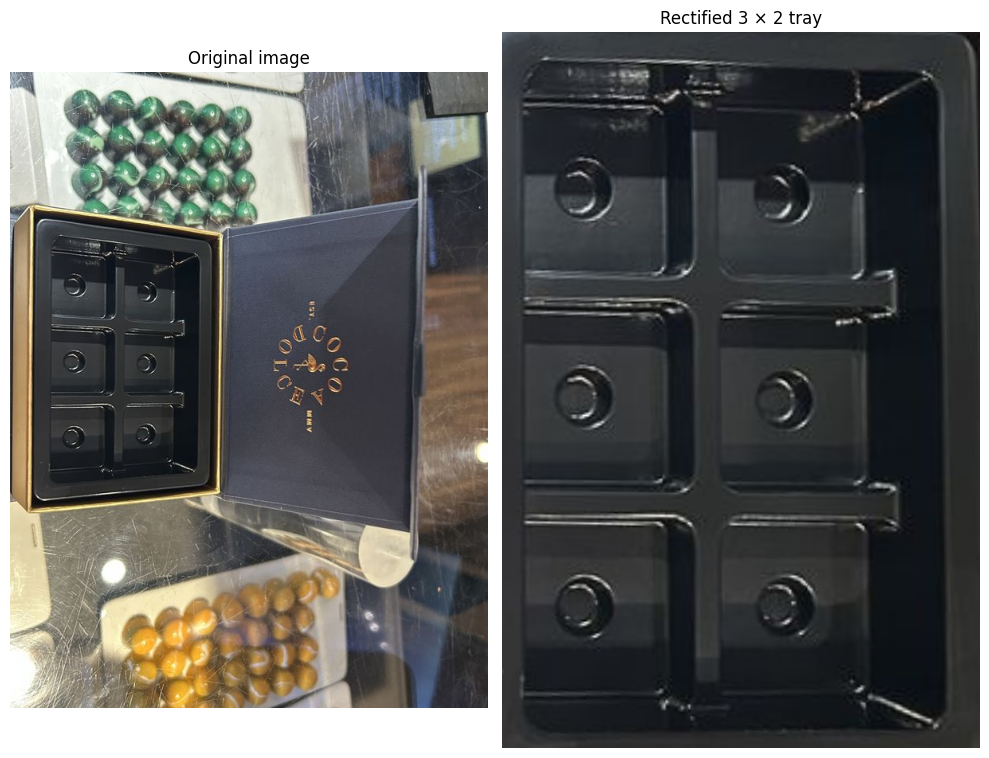

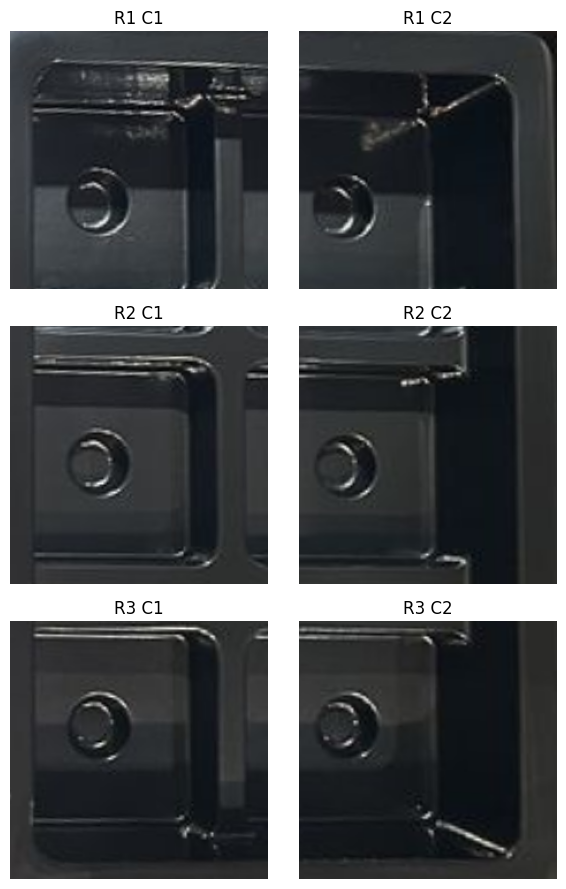

Extracted 6 slots; expected 6


In [8]:
# GRID_SHAPES={6:(3,2),16:(4,4),30:(5,6),50:(5,10)}
GRID_SHAPES={6:(3,2),16:(4,4),30:(6,5),50:(10,5)}
rows,cols=GRID_SHAPES[predicted_capacity]
tray_width,tray_height=cols*224,rows*224

source=predicted_corners.astype(np.float32)
destination=np.array([[0,0],[tray_width-1,0],[tray_width-1,tray_height-1],[0,tray_height-1]],dtype=np.float32)
perspective_matrix=cv2.getPerspectiveTransform(source,destination)
rectified_rgb=cv2.warpPerspective(image_rgb,perspective_matrix,(tray_width,tray_height))

slots=[]
for row in range(rows):
    for col in range(cols):
        slot=rectified_rgb[row*224:(row+1)*224,col*224:(col+1)*224]
        slots.append({"row":row,"column":col,"image":slot})

fig,axes=plt.subplots(1,2,figsize=(10,10))
axes[0].imshow(image_rgb)
axes[0].set_title("Original image")
axes[1].imshow(rectified_rgb)
axes[1].set_title(f"Rectified {rows} × {cols} tray")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

fig,axes=plt.subplots(rows,cols,figsize=(cols*3,rows*3))
axes=np.asarray(axes).reshape(rows,cols)
for item,axis in zip(slots,axes.flat):
    axis.imshow(item["image"])
    axis.set_title(f"R{item['row']+1} C{item['column']+1}")
    axis.axis("off")
plt.tight_layout()
plt.show()

print(f"Extracted {len(slots)} slots; expected {predicted_capacity}")
assert len(slots)==predicted_capacity

In [9]:
slot_batch=torch.stack([
    model_transform(Image.fromarray(item["image"])) for item in slots
]).to(DEVICE)

normalized_prototypes=F.normalize(PROTOTYPES,dim=1)

with torch.inference_mode():
    embeddings=feature_model(slot_batch)
    similarities=embeddings@normalized_prototypes.T
    top_values,top_indices=similarities.topk(2,dim=1)

predicted_indices=top_indices[:,0].cpu().numpy()
top_scores=top_values[:,0].cpu().numpy()
margins=(top_values[:,0]-top_values[:,1]).cpu().numpy()

records=[]
for item,index,score,margin in zip(slots,predicted_indices,top_scores,margins):
    class_row=CATALOG.iloc[int(index)]
    records.append({
        "row":item["row"]+1,
        "column":item["column"]+1,
        "class_index":int(index),
        "flavor_id":class_row["flavor_id"],
        "flavor_name":class_row["flavor_name"],
        "label_type":class_row["label_type"],
        "similarity":float(score),
        "margin":float(margin),
        "needs_review":bool(margin<CONFIG["provisional_margin_threshold"])
    })

predictions=pd.DataFrame(records)
display(predictions)

occupied=predictions[predictions["label_type"]=="occupied"]
counts=occupied.groupby(["flavor_id","flavor_name"]).size().rename("count").reset_index()
print(f"Occupied: {len(occupied)} | Empty: {(predictions['label_type']=='empty').sum()} | Total slots: {len(predictions)}")
display(counts if len(counts) else pd.DataFrame({"result":["No chocolates detected"]}))

,row,column,class_index,flavor_id,flavor_name,label_type,similarity,margin,needs_review
0,1,1,6,empty,Empty,empty,0.623357,0.284171,False
1,1,2,6,empty,Empty,empty,0.597408,0.199003,False
2,2,1,6,empty,Empty,empty,0.669816,0.309854,False
3,2,2,6,empty,Empty,empty,0.588594,0.289964,False
4,3,1,6,empty,Empty,empty,0.702484,0.337196,False
5,3,2,6,empty,Empty,empty,0.657426,0.315414,False


Occupied: 0 | Empty: 6 | Total slots: 6


,result
0,No chocolates detected


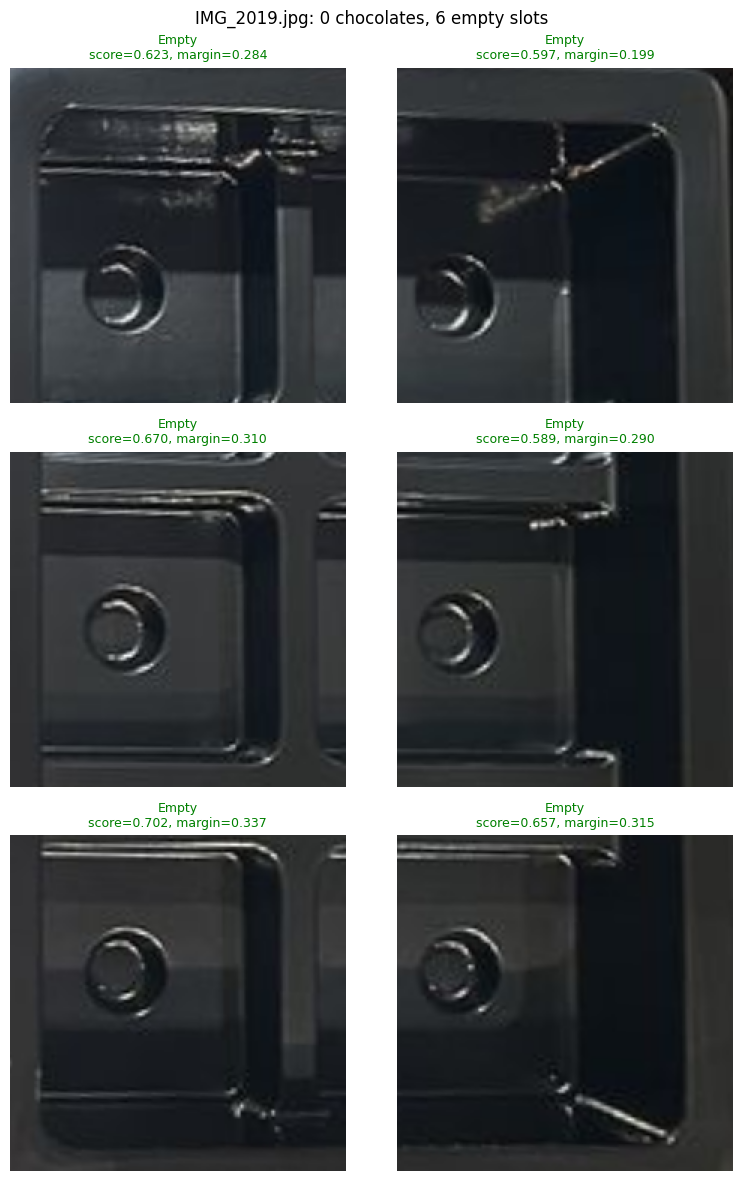

In [10]:
fig,axes=plt.subplots(rows,cols,figsize=(cols*4,rows*4))
axes=np.asarray(axes).reshape(rows,cols)

for item,record,axis in zip(slots,records,axes.flat):
    color="red" if record["needs_review"] else ("green" if record["label_type"]=="empty" else "blue")
    axis.imshow(item["image"])
    axis.set_title(f"{record['flavor_name']}\nscore={record['similarity']:.3f}, margin={record['margin']:.3f}",color=color,fontsize=9)
    axis.axis("off")

plt.suptitle(f"{TEST_IMAGE.name}: {len(occupied)} chocolates, {len(predictions)-len(occupied)} empty slots")
plt.tight_layout()
plt.show()

In [12]:
def run_inference(image_path):
    started=time.perf_counter()
    pil=ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    rgb=np.asarray(pil)
    height,width=rgb.shape[:2]
    tensor=model_transform(pil).unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        size_probs=box_size_model(tensor).softmax(1)[0]
        capacity=BOX_CLASSES[int(size_probs.argmax())]
        corners=corner_model(tensor)[0].reshape(4,2).cpu().numpy()*np.array([width,height],np.float32)

    rows,cols=GRID_SHAPES[capacity]
    tray_width,tray_height=cols*224,rows*224
    target=np.array([[0,0],[tray_width-1,0],[tray_width-1,tray_height-1],[0,tray_height-1]],np.float32)
    matrix=cv2.getPerspectiveTransform(corners.astype(np.float32),target)
    tray=cv2.warpPerspective(rgb,matrix,(tray_width,tray_height))
    crops=[tray[r*224:(r+1)*224,c*224:(c+1)*224] for r in range(rows) for c in range(cols)]
    batch=torch.stack([model_transform(Image.fromarray(crop)) for crop in crops]).to(DEVICE)

    with torch.inference_mode():
        embeddings=feature_model(batch)
        similarities=embeddings@normalized_prototypes.T
        values,indices=similarities.topk(2,dim=1)

    records=[]
    for slot,(r,c),index,score,margin in zip(crops,[(r,c) for r in range(rows) for c in range(cols)],indices[:,0].cpu().numpy(),values[:,0].cpu().numpy(),(values[:,0]-values[:,1]).cpu().numpy()):
        info=CATALOG.iloc[int(index)]
        records.append({
            "image":Path(image_path).name,"row":r+1,"column":c+1,"capacity":capacity,
            "flavor_id":info["flavor_id"],"flavor_name":info["flavor_name"],
            "label_type":info["label_type"],"similarity":float(score),"margin":float(margin),
            "needs_review":bool(margin<CONFIG["provisional_margin_threshold"])
        })

    frame=pd.DataFrame(records)
    return {
        "image_path":Path(image_path),"rgb":rgb,"corners":corners,"tray":tray,"crops":crops,
        "capacity":capacity,"size_confidence":float(size_probs.max()),"predictions":frame,
        "occupied":int((frame["label_type"]=="occupied").sum()),
        "empty":int((frame["label_type"]=="empty").sum()),
        "review":int(frame["needs_review"].sum()),
        "elapsed_seconds":time.perf_counter()-started
    }

In [13]:
preview_dir=ROOT/"data/boxes/previews"
test_images=sorted([p for p in preview_dir.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS])
assert len(test_images)==16,f"Expected 16 previews, found {len(test_images)}"

def expected_capacity(path):
    number=int(path.stem.split("_")[-1])
    return 6 if number<=2021 else 16 if number<=2026 else 30 if number<=2030 else 50

all_predictions=[]
summaries=[]

for path in test_images:
    result=run_inference(path)
    expected=expected_capacity(path)
    all_predictions.append(result["predictions"])
    summaries.append({
        "image":path.name,"expected_capacity":expected,"predicted_capacity":result["capacity"],
        "capacity_correct":expected==result["capacity"],"size_confidence":result["size_confidence"],
        "slots":len(result["predictions"]),"empty":result["empty"],"false_occupied":result["occupied"],
        "review":result["review"],"seconds":result["elapsed_seconds"]
    })
    print(f"{path.name}: expected={expected}, predicted={result['capacity']}, empty={result['empty']}, false occupied={result['occupied']}, time={result['elapsed_seconds']:.2f}s")

summary_df=pd.DataFrame(summaries)
prediction_df=pd.concat(all_predictions,ignore_index=True)

output_dir=ROOT/"outputs/final_inference_validation"
output_dir.mkdir(parents=True,exist_ok=True)
summary_df.to_csv(output_dir/"empty_box_summary.csv",index=False)
prediction_df.to_csv(output_dir/"empty_box_slot_predictions.csv",index=False)

print("\nFINAL EMPTY-BOX VALIDATION")
print(f"Box-size accuracy: {summary_df['capacity_correct'].mean():.2%}")
print(f"Empty-slot accuracy: {(prediction_df['label_type']=='empty').mean():.2%}")
print(f"False occupied slots: {(prediction_df['label_type']=='occupied').sum()}")
print(f"Review slots: {prediction_df['needs_review'].sum()}")
print(f"Mean CPU time: {summary_df['seconds'].mean():.2f} seconds/image")
display(summary_df)

IMG_2019.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.07s
IMG_2020.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.22s
IMG_2021.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.09s
IMG_2022.jpg: expected=16, predicted=16, empty=12, false occupied=4, time=0.25s
IMG_2023.jpg: expected=16, predicted=16, empty=11, false occupied=5, time=0.24s
IMG_2024.jpg: expected=16, predicted=16, empty=11, false occupied=5, time=0.14s
IMG_2025.jpg: expected=16, predicted=16, empty=10, false occupied=6, time=0.16s
IMG_2026.jpg: expected=16, predicted=16, empty=9, false occupied=7, time=0.15s
IMG_2027.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.37s
IMG_2028.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.34s
IMG_2029.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.35s
IMG_2030.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.66s
IMG_2031.jpg: expected=50, predicted=50, empty=50,

,image,expected_capacity,predicted_capacity,capacity_correct,size_confidence,slots,empty,false_occupied,review,seconds
0,IMG_2019.jpg,6,6,True,0.999991,6,6,0,0,0.066502
1,IMG_2020.jpg,6,6,True,0.999997,6,6,0,0,0.218707
2,IMG_2021.jpg,6,6,True,0.999994,6,6,0,0,0.089480
3,IMG_2022.jpg,16,16,True,0.999987,16,12,4,2,0.246897
4,IMG_2023.jpg,16,16,True,0.999974,16,11,5,3,0.238158
5,IMG_2024.jpg,16,16,True,1.000000,16,11,5,1,0.144191
6,IMG_2025.jpg,16,16,True,1.000000,16,10,6,2,0.159705
7,IMG_2026.jpg,16,16,True,1.000000,16,9,7,2,0.154321
8,IMG_2027.jpg,30,30,True,0.999989,30,30,0,0,0.368495
9,IMG_2028.jpg,30,30,True,1.000000,30,30,0,0,0.344824


False predictions by class:


,flavor_id,flavor_name,count
0,truffle_pineapple_moscato,Pineapple & Moscato,15
1,truffle_grey_salt_caramel,Grey Salt Caramel,5
2,truffle_caramel_apple_cider,Caramel Apple Cider,5
3,truffle_amaretto,Amaretto,1
4,truffle_espresso_martini,Espresso Martini,1


False predictions by grid position:


,row,column,count
0,4,1,5
1,4,4,5
2,1,1,3
3,2,3,2
4,1,3,2
5,1,2,2
6,2,4,1
7,2,2,1
8,3,1,1
9,3,2,1


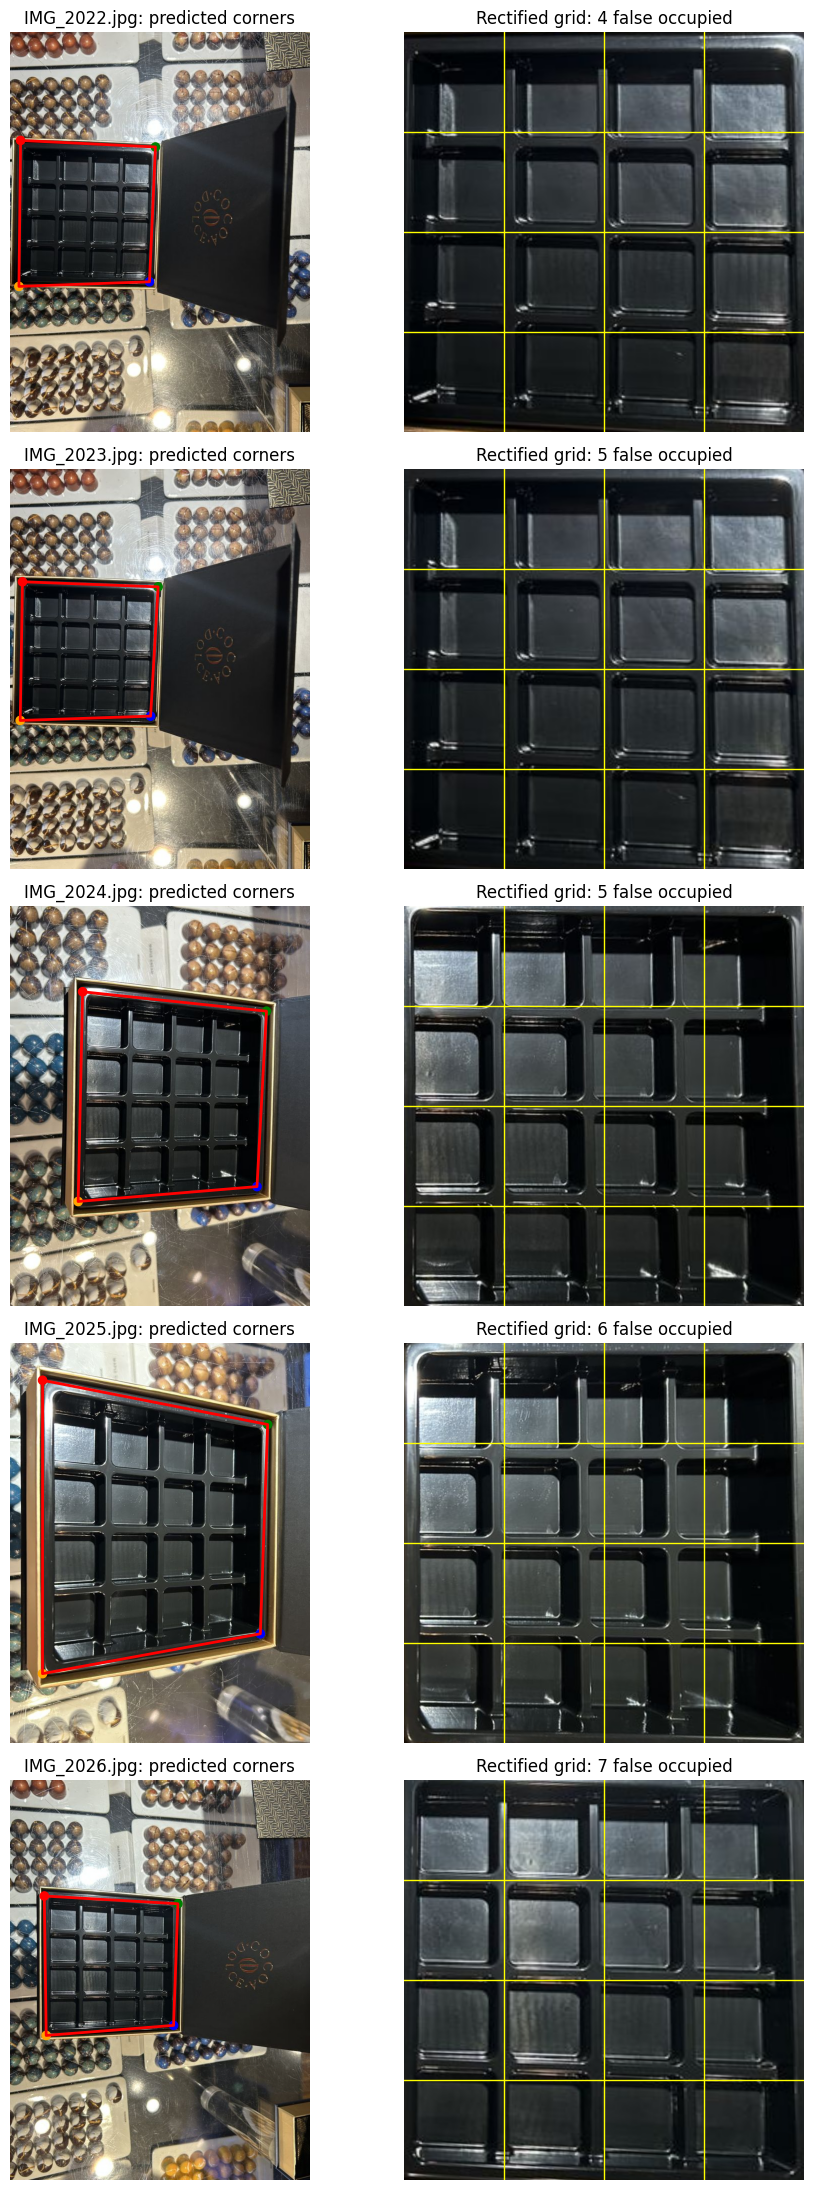

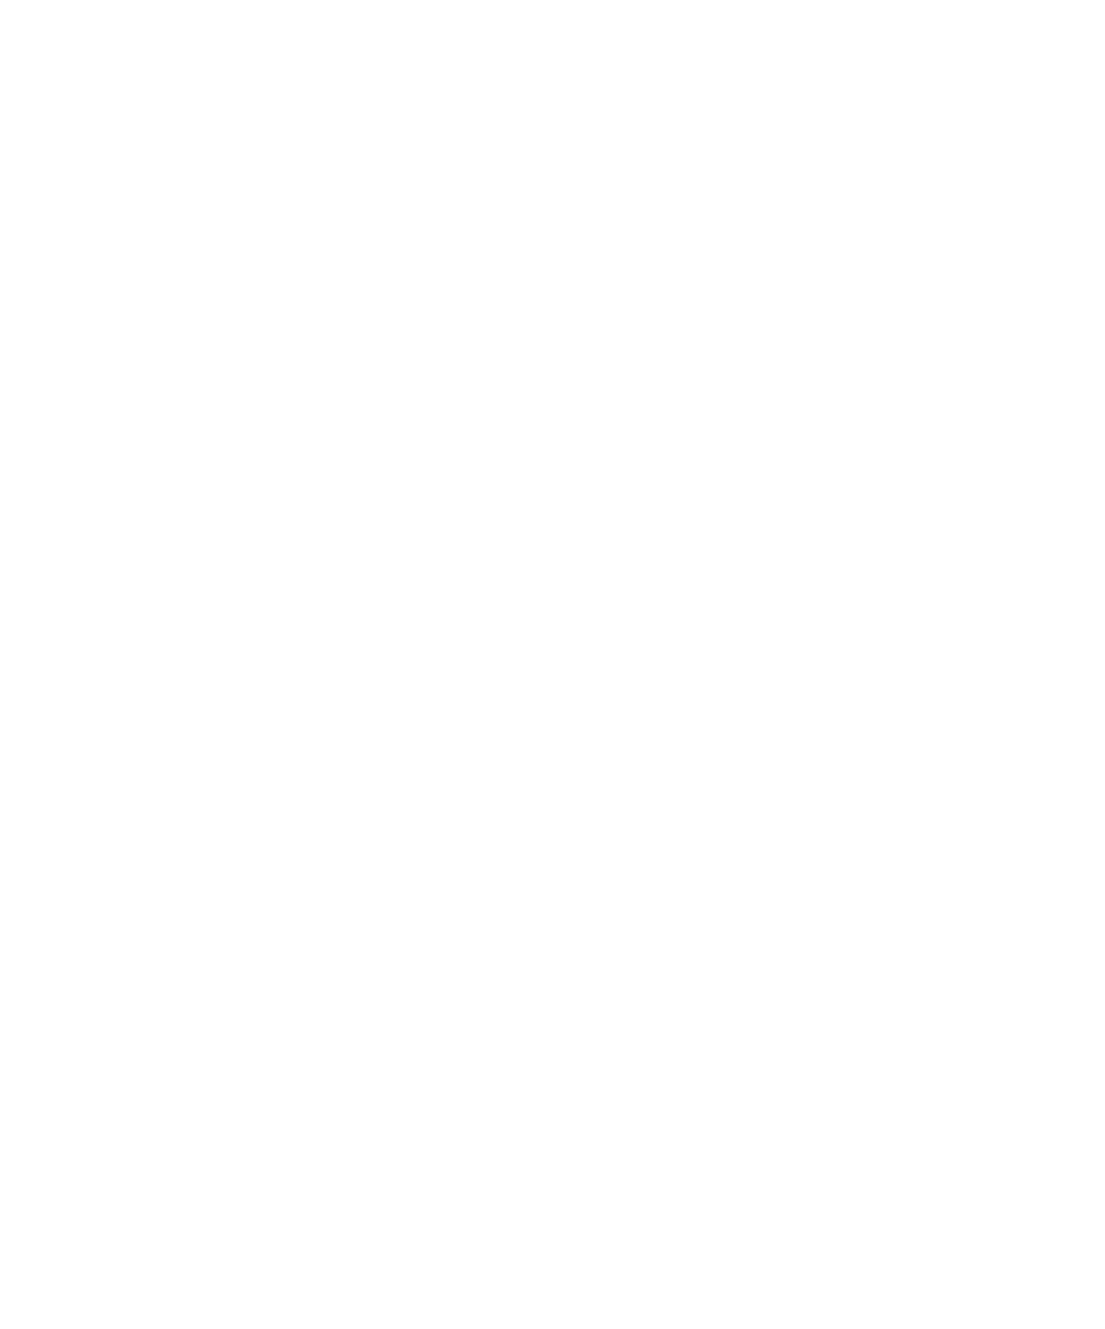

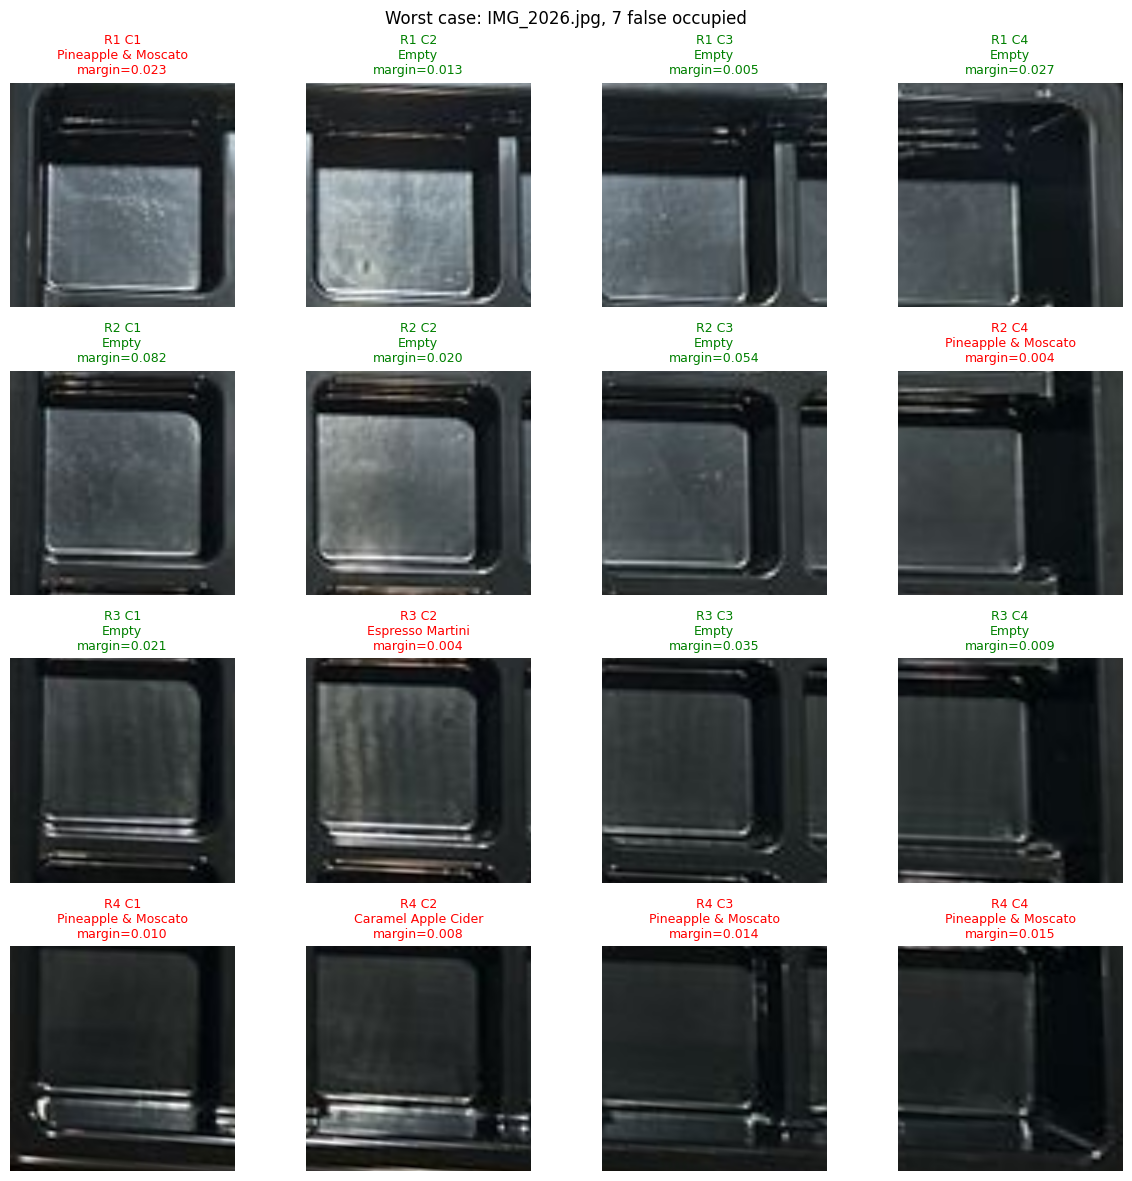

In [14]:
sixteen_results=[run_inference(path) for path in test_images if expected_capacity(path)==16]

false_predictions=pd.concat([
    result["predictions"].query("label_type == 'occupied'") for result in sixteen_results
],ignore_index=True)

print("False predictions by class:")
display(false_predictions.groupby(["flavor_id","flavor_name"]).size().rename("count").sort_values(ascending=False).reset_index())

print("False predictions by grid position:")
display(false_predictions.groupby(["row","column"]).size().rename("count").sort_values(ascending=False).reset_index())

fig,axes=plt.subplots(len(sixteen_results),2,figsize=(10,22))
for row,result in enumerate(sixteen_results):
    axes[row,0].imshow(result["rgb"])
    polygon=np.vstack([result["corners"],result["corners"][0]])
    axes[row,0].plot(polygon[:,0],polygon[:,1],"r-",linewidth=2)
    axes[row,0].scatter(result["corners"][:,0],result["corners"][:,1],c=["red","green","blue","orange"],s=35)
    axes[row,0].set_title(f"{result['image_path'].name}: predicted corners")
    axes[row,0].axis("off")

    axes[row,1].imshow(result["tray"])
    rows,cols=GRID_SHAPES[result["capacity"]]
    for r in range(1,rows):
        axes[row,1].axhline(r*224,color="yellow",linewidth=1)
    for c in range(1,cols):
        axes[row,1].axvline(c*224,color="yellow",linewidth=1)
    axes[row,1].set_title(f"Rectified grid: {result['occupied']} false occupied")
    axes[row,1].axis("off")

plt.tight_layout()
plt.show()

fig,axes=plt.subplots(5,4,figsize=(14,17))
for result,axis_row in zip(sixteen_results,axes):
    for item,record,axis in zip(result["crops"],result["predictions"].to_dict("records"),axis_row):
        pass
    false_set={(r["row"],r["column"]) for r in result["predictions"].query("label_type=='occupied'").to_dict("records")}
    for index,axis in enumerate(axis_row):
        axis.axis("off")
    tray_axis=axis_row[0]

# Show every slot from the worst 16-slot box
worst=max(sixteen_results,key=lambda result:result["occupied"])
fig,axes=plt.subplots(4,4,figsize=(12,12))
for crop,record,axis in zip(worst["crops"],worst["predictions"].to_dict("records"),axes.flat):
    color="red" if record["label_type"]=="occupied" else "green"
    axis.imshow(crop)
    axis.set_title(f"R{record['row']} C{record['column']}\n{record['flavor_name']}\nmargin={record['margin']:.3f}",color=color,fontsize=9)
    axis.axis("off")
plt.suptitle(f"Worst case: {worst['image_path'].name}, {worst['occupied']} false occupied")
plt.tight_layout()
plt.show()

In [15]:
import json

slot_manifest_path=ROOT/"data/boxes/slots/empty_slots_manifest.csv"
slot_manifest=pd.read_csv(slot_manifest_path)

print("SLOT MANIFEST COLUMNS:")
print(slot_manifest.columns.tolist())
display(slot_manifest.head(10))

print("\n16-SLOT RECORDS:")
capacity_column=next((c for c in slot_manifest.columns if c.lower() in {"capacity","box_size","slot_count","box_capacity"}),None)
if capacity_column:
    display(slot_manifest[slot_manifest[capacity_column].astype(str)=="16"].head(20))
else:
    print("Capacity column not automatically identified.")

print("\nGRID ANNOTATION FILES:")
grid_files=sorted([
    p for p in ROOT.rglob("*.json")
    if "grid" in p.name.lower() or "annotation" in str(p.parent).lower()
])
for path in grid_files[:40]:
    print(path.relative_to(ROOT))

if grid_files:
    print("\nSAMPLE GRID JSON:")
    sample=grid_files[0]
    print("File:",sample)
    print(json.dumps(json.loads(sample.read_text()),indent=2)[:5000])

SLOT MANIFEST COLUMNS:
['slot_file', 'slot_path', 'source_file', 'box_size', 'row', 'column', 'center_x', 'center_y', 'label', 'grid_annotation']


,slot_file,slot_path,source_file,box_size,row,column,center_x,center_y,label,grid_annotation
0,IMG_2019_r01_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,1,1,85.0,174.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
1,IMG_2019_r01_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,1,2,299.0,178.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
2,IMG_2019_r02_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,2,1,90.0,387.5,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
3,IMG_2019_r02_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,2,2,299.5,389.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
4,IMG_2019_r03_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,3,1,95.0,601.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
5,IMG_2019_r03_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2019.jpg,6,3,2,300.0,600.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
6,IMG_2020_r01_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2020.jpg,6,1,1,142.0,195.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
7,IMG_2020_r01_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2020.jpg,6,1,2,370.0,191.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
8,IMG_2020_r02_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2020.jpg,6,2,1,143.5,409.5,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
9,IMG_2020_r02_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2020.jpg,6,2,2,364.0,411.0,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...



16-SLOT RECORDS:


,slot_file,slot_path,source_file,box_size,row,column,center_x,center_y,label,grid_annotation
18,IMG_2022_r01_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,1,1,194.56,190.17,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
19,IMG_2022_r01_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,1,2,419.84,193.10,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
20,IMG_2022_r01_c03.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,1,3,645.12,196.02,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
21,IMG_2022_r01_c04.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,1,4,870.40,198.95,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
22,IMG_2022_r02_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,2,1,186.27,416.43,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
23,IMG_2022_r02_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,2,2,414.15,420.82,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
24,IMG_2022_r02_c03.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,2,3,642.03,425.20,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
25,IMG_2022_r02_c04.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,2,4,869.91,429.59,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
26,IMG_2022_r03_c01.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,3,1,177.98,642.68,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...
27,IMG_2022_r03_c02.jpg,/homes/mxqasim/Chocolathon/data/boxes/slots/em...,IMG_2022.jpg,16,3,2,408.46,648.53,empty,/homes/mxqasim/Chocolathon/data/boxes/grid_ann...



GRID ANNOTATION FILES:
data/boxes/annotations/IMG_2019.json
data/boxes/annotations/IMG_2020.json
data/boxes/annotations/IMG_2021.json
data/boxes/annotations/IMG_2022.json
data/boxes/annotations/IMG_2023.json
data/boxes/annotations/IMG_2024.json
data/boxes/annotations/IMG_2025.json
data/boxes/annotations/IMG_2026.json
data/boxes/annotations/IMG_2027.json
data/boxes/annotations/IMG_2028.json
data/boxes/annotations/IMG_2029.json
data/boxes/annotations/IMG_2030.json
data/boxes/annotations/IMG_2031.json
data/boxes/annotations/IMG_2032.json
data/boxes/annotations/IMG_2033.json
data/boxes/annotations/IMG_2034.json
data/boxes/grid_annotations/IMG_2019.json
data/boxes/grid_annotations/IMG_2020.json
data/boxes/grid_annotations/IMG_2021.json
data/boxes/grid_annotations/IMG_2022.json
data/boxes/grid_annotations/IMG_2023.json
data/boxes/grid_annotations/IMG_2024.json
data/boxes/grid_annotations/IMG_2025.json
data/boxes/grid_annotations/IMG_2026.json
data/boxes/grid_annotations/IMG_2027.json
data/b

In [16]:
false_occupied=prediction_df.query("label_type == 'occupied'")

print("AUTOMATIC EMPTY-BOX FALSE-OCCUPIED DISTRIBUTION")
display(false_occupied[["image","row","column","flavor_name","similarity","margin"]].sort_values("margin",ascending=False))
print(false_occupied[["similarity","margin"]].describe(percentiles=[.25,.5,.75,.9,.95,.99]))
print("Maximum false-occupied margin:",false_occupied["margin"].max())

validation_path=ROOT/"data/experiments/synthetic_slot_embeddings_v1/outputs/validation_prototype_predictions.csv"
assert validation_path.exists(),validation_path
validation_predictions=pd.read_csv(validation_path)

print("\nSYNTHETIC VALIDATION COLUMNS")
print(validation_predictions.columns.tolist())
display(validation_predictions.head())
print("\nDATA TYPES/CLASSES")
for column in validation_predictions.columns:
    if any(word in column.lower() for word in ["true","label","type","margin","similarity","score","predict"]):
        print(column,validation_predictions[column].nunique(),validation_predictions[column].dropna().astype(str).unique()[:10])

AUTOMATIC EMPTY-BOX FALSE-OCCUPIED DISTRIBUTION


,image,row,column,flavor_name,similarity,margin
72,IMG_2025.jpg,2,3,Grey Salt Caramel,0.426647,0.043000
18,IMG_2022.jpg,1,1,Pineapple & Moscato,0.372937,0.035142
71,IMG_2025.jpg,2,2,Grey Salt Caramel,0.427735,0.028670
81,IMG_2025.jpg,4,4,Pineapple & Moscato,0.387741,0.026461
34,IMG_2023.jpg,1,1,Pineapple & Moscato,0.365278,0.024847
46,IMG_2023.jpg,4,1,Caramel Apple Cider,0.292345,0.024650
82,IMG_2026.jpg,1,1,Pineapple & Moscato,0.435566,0.023204
76,IMG_2025.jpg,3,3,Grey Salt Caramel,0.394856,0.022001
314,IMG_2032.jpg,10,2,Espresso Martini,0.418408,0.020364
97,IMG_2026.jpg,4,4,Pineapple & Moscato,0.314272,0.014995


       similarity     margin
count   28.000000  28.000000
mean     0.362782   0.014707
std      0.055651   0.010424
min      0.265275   0.003308
25%      0.312970   0.006027
50%      0.368000   0.012045
75%      0.400744   0.022302
90%      0.428643   0.027124
95%      0.433885   0.032876
99%      0.466109   0.040878
max      0.477405   0.043000
Maximum false-occupied margin: 0.04300004243850708

SYNTHETIC VALIDATION COLUMNS
['sample_id', 'relative_path', 'true_flavor_id', 'true_flavor_name', 'predicted_flavor_id', 'predicted_flavor_name', 'top1_similarity', 'similarity_margin', 'top2_flavor_id', 'top3_flavor_id', 'top3_correct', 'label_type', 'empty_source_file', 'box_size', 'extraction_method']


,sample_id,relative_path,true_flavor_id,true_flavor_name,predicted_flavor_id,predicted_flavor_name,top1_similarity,similarity_margin,top2_flavor_id,top3_flavor_id,top3_correct,label_type,empty_source_file,box_size,extraction_method
0,cocoashot_amaretto_0081,data/synthetic_slots/v1/dataset/images/validat...,cocoashot_amaretto,Amaretto,cocoashot_amaretto,Amaretto,0.854104,0.273447,truffle_pineapple_moscato,cocoashot_whiskey,True,occupied,IMG_2020.jpg,6,expanded_u2net
1,cocoashot_amaretto_0082,data/synthetic_slots/v1/dataset/images/validat...,cocoashot_amaretto,Amaretto,cocoashot_amaretto,Amaretto,0.875996,0.304796,cocoashot_whiskey,truffle_pumpkin_spice_latte,True,occupied,IMG_2023.jpg,16,expanded_u2net
2,cocoashot_amaretto_0083,data/synthetic_slots/v1/dataset/images/validat...,cocoashot_amaretto,Amaretto,cocoashot_amaretto,Amaretto,0.725083,0.187387,cocoashot_whiskey,truffle_pumpkin_spice_latte,True,occupied,IMG_2030.jpg,30,expanded_u2net
3,cocoashot_amaretto_0084,data/synthetic_slots/v1/dataset/images/validat...,cocoashot_amaretto,Amaretto,cocoashot_amaretto,Amaretto,0.854283,0.249926,cocoashot_whiskey,truffle_espresso_martini,True,occupied,IMG_2034.jpg,50,expanded_u2net
4,cocoashot_amaretto_0085,data/synthetic_slots/v1/dataset/images/validat...,cocoashot_amaretto,Amaretto,cocoashot_amaretto,Amaretto,0.846972,0.308892,cocoashot_whiskey,truffle_pineapple_moscato,True,occupied,IMG_2020.jpg,6,expanded_u2net



DATA TYPES/CLASSES
true_flavor_id 34 ['cocoashot_amaretto' 'cocoashot_bourbon' 'cocoashot_chocolate_cake'
 'cocoashot_old_fashioned' 'cocoashot_tequila' 'cocoashot_whiskey'
 'truffle_amaretto' 'truffle_bananas_foster' 'truffle_brownie_batter'
 'truffle_caramel_apple_cider']
true_flavor_name 33 ['Amaretto' 'Bourbon' 'Chocolate Cake' 'Old Fashioned' 'Tequila' 'Whiskey'
 'Bananas Foster' 'Brownie Batter' 'Caramel Apple Cider' 'Champagne']
predicted_flavor_id 34 ['cocoashot_amaretto' 'cocoashot_bourbon' 'cocoashot_chocolate_cake'
 'cocoashot_old_fashioned' 'cocoashot_tequila' 'cocoashot_whiskey'
 'truffle_amaretto' 'truffle_bananas_foster' 'truffle_brownie_batter'
 'truffle_caramel_apple_cider']
predicted_flavor_name 33 ['Amaretto' 'Bourbon' 'Chocolate Cake' 'Old Fashioned' 'Tequila' 'Whiskey'
 'Bananas Foster' 'Brownie Batter' 'Caramel Apple Cider' 'Champagne']
top1_similarity 762 ['0.85410404' '0.8759959' '0.7250832' '0.85428274' '0.8469719' '0.8809691'
 '0.8289696' '0.8543607' '0.84818

In [17]:
normalized_candidates=[
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    and "normalized" in str(p).lower()
    and p.stem.upper() in {f"IMG_{i}" for i in range(2019,2035)}
]

print("NORMALIZED TRAY SIZES")
normalized_sizes={}
for path in sorted(normalized_candidates):
    image=Image.open(path)
    normalized_sizes[path.stem]=(image.width,image.height)
    print(path.relative_to(ROOT),image.size)

print("\nGRID JSON EXAMPLES")
for image_id in ["IMG_2019","IMG_2022","IMG_2027","IMG_2031"]:
    path=ROOT/f"data/boxes/grid_annotations/{image_id}.json"
    print(f"\n{path.relative_to(ROOT)}")
    print(json.dumps(json.loads(path.read_text()),indent=2)[:4000])

geometry=slot_manifest.groupby(["box_size","row","column"]).agg(
    center_x=("center_x","mean"),
    center_y=("center_y","mean"),
    center_x_std=("center_x","std"),
    center_y_std=("center_y","std"),
    samples=("source_file","count")
).reset_index()

print("\nCANONICAL SLOT CENTERS")
display(geometry)

print("\nCOORDINATE RANGES BY CAPACITY")
display(geometry.groupby("box_size").agg(
    min_x=("center_x","min"),max_x=("center_x","max"),
    min_y=("center_y","min"),max_y=("center_y","max"),
    max_x_std=("center_x_std","max"),max_y_std=("center_y_std","max")
))

NORMALIZED TRAY SIZES
data/boxes/normalized/IMG_2019.jpg (512, 768)
data/boxes/normalized/IMG_2020.jpg (512, 768)
data/boxes/normalized/IMG_2021.jpg (512, 768)
data/boxes/normalized/IMG_2022.jpg (1024, 1024)
data/boxes/normalized/IMG_2023.jpg (1024, 1024)
data/boxes/normalized/IMG_2024.jpg (1024, 1024)
data/boxes/normalized/IMG_2025.jpg (1024, 1024)
data/boxes/normalized/IMG_2026.jpg (1024, 1024)
data/boxes/normalized/IMG_2027.jpg (1280, 1536)
data/boxes/normalized/IMG_2028.jpg (1280, 1536)
data/boxes/normalized/IMG_2029.jpg (1280, 1536)
data/boxes/normalized/IMG_2030.jpg (1280, 1536)
data/boxes/normalized/IMG_2031.jpg (1280, 2560)
data/boxes/normalized/IMG_2032.jpg (1280, 2560)
data/boxes/normalized/IMG_2033.jpg (1280, 2560)
data/boxes/normalized/IMG_2034.jpg (1280, 2560)

GRID JSON EXAMPLES

data/boxes/grid_annotations/IMG_2019.json
{
  "file": "IMG_2019.jpg",
  "box_size": 6,
  "rows": 3,
  "columns": 2,
  "anchors": {
    "top_left": [
      85.0,
      174.0
    ],
    "top_right"

,box_size,row,column,center_x,center_y,center_x_std,center_y_std,samples
0,6,1,1,111.666667,181.000000,28.676355,12.124356,3
1,6,1,2,335.333333,181.000000,35.529331,8.888194,3
2,6,2,1,114.500000,395.000000,27.032388,12.559857,3
3,6,2,2,333.333333,396.666667,32.366392,12.423097,3
4,6,3,1,117.333333,609.000000,25.423087,13.000000,3
...,...,...,...,...,...,...,...,...
97,50,10,1,130.845000,2340.980000,48.660325,9.574727,4
98,50,10,2,364.797500,2342.932500,45.735863,8.600362,4
99,50,10,3,598.757500,2344.890000,42.868977,9.529012,4
100,50,10,4,832.712500,2346.845000,40.079835,11.929064,4



COORDINATE RANGES BY CAPACITY


,min_x,max_x,min_y,max_y,max_x_std,max_y_std
box_size,,,,,,
6,111.666667,335.333333,181.0000,612.333333,35.529331,16.441817
16,132.244000,826.222000,183.1500,867.182000,46.292244,16.724864
30,123.427500,1046.397500,197.9425,1346.742500,64.760260,18.547707
50,117.335000,1076.622500,210.4900,2348.800000,53.237771,15.119266


In [18]:
CANVAS_SIZES={6:(512,768),16:(1024,1024),30:(1280,1536),50:(1280,2560)}
CANONICAL_CENTERS={
    int(capacity):group.sort_values(["row","column"])[["row","column","center_x","center_y"]].to_dict("records")
    for capacity,group in geometry.groupby("box_size")
}

def crop_centered(image,center_x,center_y,size=224):
    half=size//2
    x1,y1=int(round(center_x))-half,int(round(center_y))-half
    x2,y2=x1+size,y1+size
    crop=image[max(0,y1):min(image.shape[0],y2),max(0,x1):min(image.shape[1],x2)]
    if crop.shape[:2]!=(size,size):
        top,left=max(0,-y1),max(0,-x1)
        crop=cv2.copyMakeBorder(crop,top,max(0,y2-image.shape[0]),left,max(0,x2-image.shape[1]),cv2.BORDER_REFLECT_101)
    return crop[:size,:size]

def run_inference_v2(image_path):
    started=time.perf_counter()
    pil=ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    rgb=np.asarray(pil)
    height,width=rgb.shape[:2]
    tensor=model_transform(pil).unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        size_probs=box_size_model(tensor).softmax(1)[0]
        capacity=BOX_CLASSES[int(size_probs.argmax())]
        corners=corner_model(tensor)[0].reshape(4,2).cpu().numpy()*np.array([width,height],np.float32)

    canvas_width,canvas_height=CANVAS_SIZES[capacity]
    target=np.array([[0,0],[canvas_width-1,0],[canvas_width-1,canvas_height-1],[0,canvas_height-1]],np.float32)
    matrix=cv2.getPerspectiveTransform(corners.astype(np.float32),target)
    tray=cv2.warpPerspective(rgb,matrix,(canvas_width,canvas_height))

    center_records=CANONICAL_CENTERS[capacity]
    crops=[crop_centered(tray,item["center_x"],item["center_y"]) for item in center_records]
    batch=torch.stack([model_transform(Image.fromarray(crop)) for crop in crops]).to(DEVICE)

    with torch.inference_mode():
        embeddings=feature_model(batch)
        similarities=embeddings@normalized_prototypes.T
        values,indices=similarities.topk(2,dim=1)

    records=[]
    for center,index,score,margin in zip(center_records,indices[:,0].cpu().numpy(),values[:,0].cpu().numpy(),(values[:,0]-values[:,1]).cpu().numpy()):
        info=CATALOG.iloc[int(index)]
        records.append({
            "image":Path(image_path).name,"row":int(center["row"]),"column":int(center["column"]),
            "capacity":capacity,"flavor_id":info["flavor_id"],"flavor_name":info["flavor_name"],
            "label_type":info["label_type"],"similarity":float(score),"margin":float(margin),
            "needs_review":bool(margin<CONFIG["provisional_margin_threshold"])
        })

    frame=pd.DataFrame(records)
    return {
        "image_path":Path(image_path),"rgb":rgb,"corners":corners,"tray":tray,"crops":crops,
        "capacity":capacity,"size_confidence":float(size_probs.max()),"predictions":frame,
        "occupied":int((frame["label_type"]=="occupied").sum()),
        "empty":int((frame["label_type"]=="empty").sum()),
        "review":int(frame["needs_review"].sum()),
        "elapsed_seconds":time.perf_counter()-started
    }

print("Corrected geometry configured:")
for capacity in BOX_CLASSES:
    print(capacity,CANVAS_SIZES[capacity],len(CANONICAL_CENTERS[capacity]),"centers")

Corrected geometry configured:
6 (512, 768) 6 centers
16 (1024, 1024) 16 centers
30 (1280, 1536) 30 centers
50 (1280, 2560) 50 centers


In [19]:
corrected_results=[]
corrected_summaries=[]

for path in test_images:
    result=run_inference_v2(path)
    corrected_results.append(result["predictions"])
    expected=expected_capacity(path)
    corrected_summaries.append({
        "image":path.name,"expected_capacity":expected,"predicted_capacity":result["capacity"],
        "capacity_correct":expected==result["capacity"],"size_confidence":result["size_confidence"],
        "slots":len(result["predictions"]),"empty":result["empty"],"false_occupied":result["occupied"],
        "review":result["review"],"seconds":result["elapsed_seconds"]
    })
    print(f"{path.name}: expected={expected}, predicted={result['capacity']}, empty={result['empty']}, false occupied={result['occupied']}, time={result['elapsed_seconds']:.2f}s")

corrected_summary=pd.DataFrame(corrected_summaries)
corrected_predictions=pd.concat(corrected_results,ignore_index=True)

corrected_summary.to_csv(output_dir/"empty_box_summary_corrected_geometry.csv",index=False)
corrected_predictions.to_csv(output_dir/"empty_box_slot_predictions_corrected_geometry.csv",index=False)

print("\nCORRECTED EMPTY-BOX VALIDATION")
print(f"Box-size accuracy: {corrected_summary['capacity_correct'].mean():.2%}")
print(f"Empty-slot accuracy: {(corrected_predictions['label_type']=='empty').mean():.2%}")
print(f"False occupied slots: {(corrected_predictions['label_type']=='occupied').sum()}")
print(f"Review slots: {corrected_predictions['needs_review'].sum()}")
print(f"Mean CPU time: {corrected_summary['seconds'].mean():.2f} seconds/image")
display(corrected_summary)

IMG_2019.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.10s
IMG_2020.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.19s
IMG_2021.jpg: expected=6, predicted=6, empty=6, false occupied=0, time=0.07s
IMG_2022.jpg: expected=16, predicted=16, empty=11, false occupied=5, time=0.13s
IMG_2023.jpg: expected=16, predicted=16, empty=14, false occupied=2, time=0.18s
IMG_2024.jpg: expected=16, predicted=16, empty=8, false occupied=8, time=0.13s
IMG_2025.jpg: expected=16, predicted=16, empty=8, false occupied=8, time=0.14s
IMG_2026.jpg: expected=16, predicted=16, empty=7, false occupied=9, time=0.13s
IMG_2027.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.26s
IMG_2028.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.29s
IMG_2029.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.26s
IMG_2030.jpg: expected=30, predicted=30, empty=30, false occupied=0, time=0.26s
IMG_2031.jpg: expected=50, predicted=50, empty=50, f

,image,expected_capacity,predicted_capacity,capacity_correct,size_confidence,slots,empty,false_occupied,review,seconds
0,IMG_2019.jpg,6,6,True,0.999991,6,6,0,0,0.098057
1,IMG_2020.jpg,6,6,True,0.999997,6,6,0,0,0.191556
2,IMG_2021.jpg,6,6,True,0.999994,6,6,0,0,0.068152
3,IMG_2022.jpg,16,16,True,0.999987,16,11,5,3,0.132888
4,IMG_2023.jpg,16,16,True,0.999974,16,14,2,3,0.183743
5,IMG_2024.jpg,16,16,True,1.000000,16,8,8,3,0.133910
6,IMG_2025.jpg,16,16,True,1.000000,16,8,8,2,0.136537
7,IMG_2026.jpg,16,16,True,1.000000,16,7,9,6,0.132795
8,IMG_2027.jpg,30,30,True,0.999989,30,30,0,0,0.257493
9,IMG_2028.jpg,30,30,True,1.000000,30,30,0,0,0.292529
